# Image Classification with CNN for Malaria Data

### Introduction
In this notebook, we perform image classification on malaria cell images using Convolutional Neural Networks (CNN). The steps involved in this process are as follows:

1. Data Loading and Preprocessing:
    * We load the images from the cell_images/cell_images directory.
    * Each image is resized to 64x64 pixels and normalized.
    * Labels are extracted from the directory names, with Parasitized labeled as 1 and Uninfected labeled as 0.
2. Data Visualization:
    * We visualize some of the images along with their labels to understand the dataset better.
3. Model Building:
    * We build a CNN model using TensorFlow and Keras.
    * The model consists of convolutional layers, max-pooling layers, batch normalization, dropout, and dense layers.
4. Data Splitting:

    * The dataset is split into training and testing sets using train_test_split.
5. Model Training:

    * The model is trained using the training set.
    * We use early stopping to prevent overfitting.
 6. Model Evaluation:

    * The model is evaluated on the testing set to determine its accuracy and loss.
7. Data Augmentation:

    * We apply data augmentation techniques to improve the model's performance.
    * Techniques such as rotation, width shift, height shift, horizontal flip, and zoom are used.

In [1]:
import os
import glob
from PIL import Image
import numpy as np
import warnings 
warnings.filterwarnings('ignore')
# Define the path to the dataset
dataset_path = 'cell_images/cell_images'

# Get list of all image files in the dataset directory
image_files = glob.glob(os.path.join(dataset_path, '**', '*.png'), recursive=True)

# Function to load and preprocess images and extract labels
def load_images_and_labels(image_files):
    images = []
    labels = []
    for file in image_files:
        img = Image.open(file)
        img = img.resize((64, 64))  # Resize image to 64x64
        img = np.array(img) / 255.0  # Normalize pixel values
        images.append(img)
        
        # Extract label from the parent directory name
        if 'Parasitized' in file:
            labels.append(1)  # Parasitized is 1
        elif 'Uninfected' in file:
            labels.append(0)  # Uninfected is 0
        
    return np.array(images), np.array(labels)

# Load images and labels
images, labels = load_images_and_labels(image_files)

print(f'Total images loaded: {len(images)}')
print(f'Numeric Labels: {labels[:5]}')

Total images loaded: 27558
Numeric Labels: [1 1 1 1 1]


In [2]:
print("last 5 images label" , labels[-5:])
print("first 5 images label" , labels[:5])

last 5 images label [0 0 0 0 0]
first 5 images label [1 1 1 1 1]


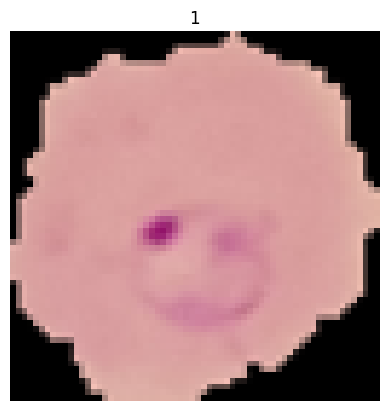

In [3]:
# plot first image
import matplotlib.pyplot as plt
plt.imshow(images[0])
plt.title(labels[0])
plt.axis('off')
plt.show()


In [4]:
# first image and label
print(images[0].shape)
print(labels[0])


(64, 64, 3)
1


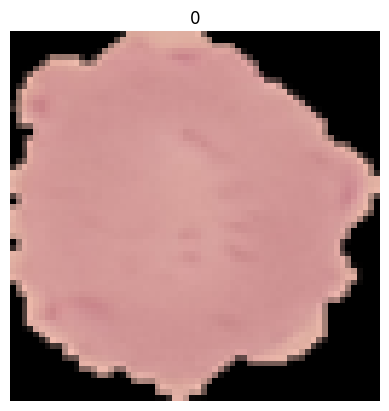

In [5]:
plt.imshow(images[-1])
plt.title(labels[-1])
plt.axis('off')
plt.show()

In [6]:
print(labels[-30:-20])

[0 0 0 0 0 0 0 0 0 0]


In [7]:
# data shape
print(images.shape)
print(labels.shape)


(27558, 64, 64, 3)
(27558,)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D,InputLayer, Reshape , BatchNormalization, Dropout

In [9]:
model = Sequential()
model.add(InputLayer(input_shape=(64,64,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(120, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Train the model
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')


Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 68s 90ms/step - accuracy: 0.7526 - loss: 0.8713 - val_accuracy: 0.9151 - val_loss: 0.2481
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 69s 71ms/step - accuracy: 0.9397 - loss: 0.1731 - val_accuracy: 0.9472 - val_loss: 0.1614
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9497 - loss: 0.1448 - val_accuracy: 0.9399 - val_loss: 0.2011
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 65s 95ms/step - accuracy: 0.9477 - loss: 0.1491 - val_accuracy: 0.9532 - val_loss: 0.1732
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 108ms/step - accuracy: 0.9511 - loss: 0.1399 - val_accuracy: 0.9517 - val_loss: 0.1740
173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9525 - loss: 0.1640
Loss: 0.17398971319198608, Accuracy: 0.951741635799408


In [11]:
# Initialize Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=50,  # Eğitim süresini artırabilirsiniz
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')


Epoch 1/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 73s 106ms/step - accuracy: 0.9584 - loss: 0.1294 - val_accuracy: 0.9487 - val_loss: 0.1712
Epoch 2/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 73s 106ms/step - accuracy: 0.9622 - loss: 0.1111 - val_accuracy: 0.9448 - val_loss: 0.1980
Epoch 3/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.9627 - loss: 0.1085 - val_accuracy: 0.9543 - val_loss: 0.1934
Epoch 4/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 85ms/step - accuracy: 0.9640 - loss: 0.1061 - val_accuracy: 0.9490 - val_loss: 0.1897
Epoch 5/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - accuracy: 0.9703 - loss: 0.0838 - val_accuracy: 0.9474 - val_loss: 0.2316
Epoch 6/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 66s 96ms/step - accuracy: 0.9694 - loss: 0.0883 - val_accuracy: 0.9517 - val_loss: 0.2512
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9512 - loss: 0.1603
Loss: 0.17124411463737488, Accuracy: 0.9486574530601501


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Veri Artırma (Data Augmentation)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15
)

datagen.fit(X_train)

# Erken Durdurma (Early Stopping)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli Eğitme
history = model.fit(datagen.flow(X_train, y_train, batch_size=64),
                    epochs=50,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])


Epoch 1/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 74s 209ms/step - accuracy: 0.9178 - loss: 0.2344 - val_accuracy: 0.9525 - val_loss: 0.1448
Epoch 2/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 65s 187ms/step - accuracy: 0.9266 - loss: 0.2099 - val_accuracy: 0.9559 - val_loss: 0.1402
Epoch 3/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 62s 180ms/step - accuracy: 0.9360 - loss: 0.1965 - val_accuracy: 0.9410 - val_loss: 0.1667
Epoch 4/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 70s 201ms/step - accuracy: 0.9366 - loss: 0.1871 - val_accuracy: 0.9575 - val_loss: 0.1314
Epoch 5/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 72s 206ms/step - accuracy: 0.9423 - loss: 0.1714 - val_accuracy: 0.9557 - val_loss: 0.1381
Epoch 6/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 79s 228ms/step - accuracy: 0.9408 - loss: 0.1749 - val_accuracy: 0.9539 - val_loss: 0.1415
Epoch 7/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 76s 219ms/step - accuracy: 0.9382 - loss: 0.1833 - val_accuracy: 0.9534 - val_loss: 0.1605
Epoch 8/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 80s 231ms/step - accuracy: 0.9423 - loss: 0

In [13]:
model = Sequential()
model.add(InputLayer(input_shape=(64,64,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(720, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(120, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [14]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Train the model
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')


Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 151s 215ms/step - accuracy: 0.7833 - loss: 0.7002 - val_accuracy: 0.9338 - val_loss: 0.1847
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 152s 220ms/step - accuracy: 0.9471 - loss: 0.1538 - val_accuracy: 0.9512 - val_loss: 0.1527
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 128s 186ms/step - accuracy: 0.9533 - loss: 0.1337 - val_accuracy: 0.9421 - val_loss: 0.1682
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 98s 141ms/step - accuracy: 0.9554 - loss: 0.1268 - val_accuracy: 0.9405 - val_loss: 0.1767
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 101s 147ms/step - accuracy: 0.9599 - loss: 0.1132 - val_accuracy: 0.9492 - val_loss: 0.1774
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9491 - loss: 0.1655
Loss: 0.1773710548877716, Accuracy: 0.949201762676239


In [15]:
# Initialize Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=50,  # Eğitim süresini artırabilirsiniz
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')


Epoch 1/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9621 - loss: 0.1068 - val_accuracy: 0.9512 - val_loss: 0.1562
Epoch 2/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 97s 141ms/step - accuracy: 0.9659 - loss: 0.0946 - val_accuracy: 0.9523 - val_loss: 0.1897
Epoch 3/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 95s 138ms/step - accuracy: 0.9681 - loss: 0.0876 - val_accuracy: 0.9430 - val_loss: 0.2229
Epoch 4/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 102s 149ms/step - accuracy: 0.9705 - loss: 0.0812 - val_accuracy: 0.9548 - val_loss: 0.1980
Epoch 5/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 96s 140ms/step - accuracy: 0.9726 - loss: 0.0743 - val_accuracy: 0.9526 - val_loss: 0.2149
Epoch 6/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 96s 139ms/step - accuracy: 0.9785 - loss: 0.0583 - val_accuracy: 0.9523 - val_loss: 0.2479
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9492 - loss: 0.1495
Loss: 0.156168594956398, Accuracy: 0.9511973857879639


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Veri Artırma (Data Augmentation)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15
)

datagen.fit(X_train)

# Erken Durdurma (Early Stopping)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli Eğitme
history = model.fit(datagen.flow(X_train, y_train, batch_size=64),
                    epochs=50,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])


Epoch 1/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.9249 - loss: 0.2250 - val_accuracy: 0.9572 - val_loss: 0.1411
Epoch 2/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 75s 214ms/step - accuracy: 0.9337 - loss: 0.1940 - val_accuracy: 0.9566 - val_loss: 0.1387
Epoch 3/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 80s 231ms/step - accuracy: 0.9402 - loss: 0.1818 - val_accuracy: 0.9579 - val_loss: 0.1284
Epoch 4/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 77s 222ms/step - accuracy: 0.9406 - loss: 0.1740 - val_accuracy: 0.9579 - val_loss: 0.1260
Epoch 5/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 75s 215ms/step - accuracy: 0.9410 - loss: 0.1762 - val_accuracy: 0.9552 - val_loss: 0.1307
Epoch 6/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 76s 218ms/step - accuracy: 0.9455 - loss: 0.1714 - val_accuracy: 0.9512 - val_loss: 0.1518
Epoch 7/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 77s 221ms/step - accuracy: 0.9403 - loss: 0.1725 - val_accuracy: 0.9604 - val_loss: 0.1366
Epoch 8/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 77s 221ms/step - accuracy: 0.9423 - loss: 0

In [17]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9567 - loss: 0.1254
Loss: 0.12600891292095184, Accuracy: 0.9579100012779236


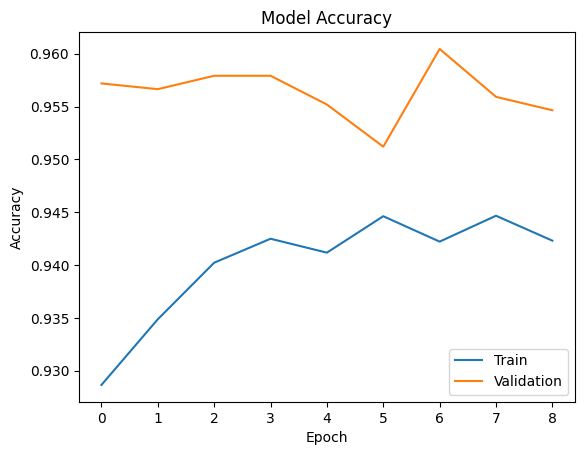

In [18]:
# plot accuray  by epoch
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()



In [19]:
# save model
model.save('malaria_model_with_data_augmentation_and_early_stopping.h5')



## Conclusion

After training and evaluating the CNN model, we achieved the following results:

- **Initial Model**:
  - The initial model without data augmentation achieved a certain level of accuracy and loss on the testing set.

- **Model with Data Augmentation**:
  - By applying data augmentation techniques, we observed an improvement in the model's performance.
  - The model with data augmentation showed better generalization and higher accuracy compared to the initial model.

**Best Method**:
- The best method for this task was the CNN model with data augmentation. The use of data augmentation techniques significantly improved the model's ability to generalize to new, unseen data, resulting in higher accuracy and lower loss on the testing set.

Overall, the CNN model with data augmentation proved to be the most effective approach for classifying malaria cell images in this study.